# 00 · Building stock inputs

The stock table brings together dwelling attributes, building geometry and the provenance of each value.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()
print(f"EnerMap - {STUDY_AREA}   |   cores: {N_JOBS}")

EnerMap - Guildford   |   cores: 32


In [2]:
import config as CFG
from ukubem import stock as S
df = S.load_stock(CFG)
df["A_floor"] = df["floor_area_final"]
bench_lsoa = S.load_benchmark_lsoa(CFG); bench_lsoa.to_csv(BENCH_LSOA, index=False)
print(f"stock table: {len(df):,} dwellings in {df['LSOA'].nunique()} LSOAs; benchmark-year population {int(df['in_calibration_population'].sum()):,}")
print(f"evidence vintage: {df['evidence_vintage'].value_counts().to_dict()}")
print(f"attributes observed on a certificate: {df['attributes_observed'].mean():.1%}   (synthesised records: {(~df['attributes_observed']).sum():,})")
print(f"roof under another dwelling (roof U-value null): {(df['roof_exposed'] == 0).sum():,}   top-storey flats: {(df['flat_top_storey'] == 'Y').sum():,}")
print(f"in the planning study area ({df['ward'].nunique()} wards): {df['in_study_area'].sum():,}   with rooftop PV potential: {(df['pv_kWp'] > 0).sum():,}")
print(f"gas-connected but not gas-heated (gas-benchmark members through cooking gas): {(df['gas_connected'] & ~df['heat_system'].isin(['Gas boiler', 'Gas communal heating'])).sum():,}")
print(f"DESNZ benchmark: {len(bench_lsoa)} LSOAs, {int(bench_lsoa['gas_meters'].sum()):,} gas meters, {int(bench_lsoa['elec_meters'].sum()):,} electricity meters")

stock table: 57,300 dwellings in 84 LSOAs; benchmark-year population 55,939
evidence vintage: {'in_window': 30384, 'synthetic': 16493, 'post_window': 10423}
attributes observed on a certificate: 71.2%   (synthesised records: 16,493)
roof under another dwelling (roof U-value null): 6,514   top-storey flats: 4,237
in the planning study area (10 wards): 28,663   with rooftop PV potential: 22,219
gas-connected but not gas-heated (gas-benchmark members through cooking gas): 297
DESNZ benchmark: 84 LSOAs, 52,142 gas meters, 58,773 electricity meters


## 1 · Observed and synthesised records

Where a dwelling has no certificate its categorical attributes were synthesised (conditioned on its LSOA and
accommodation type) before the tool starts; the flag `attributes_observed` travels through every table so
that any result can be split by evidence. The marginals below are the first check that the synthesised
records look like the certificated ones.

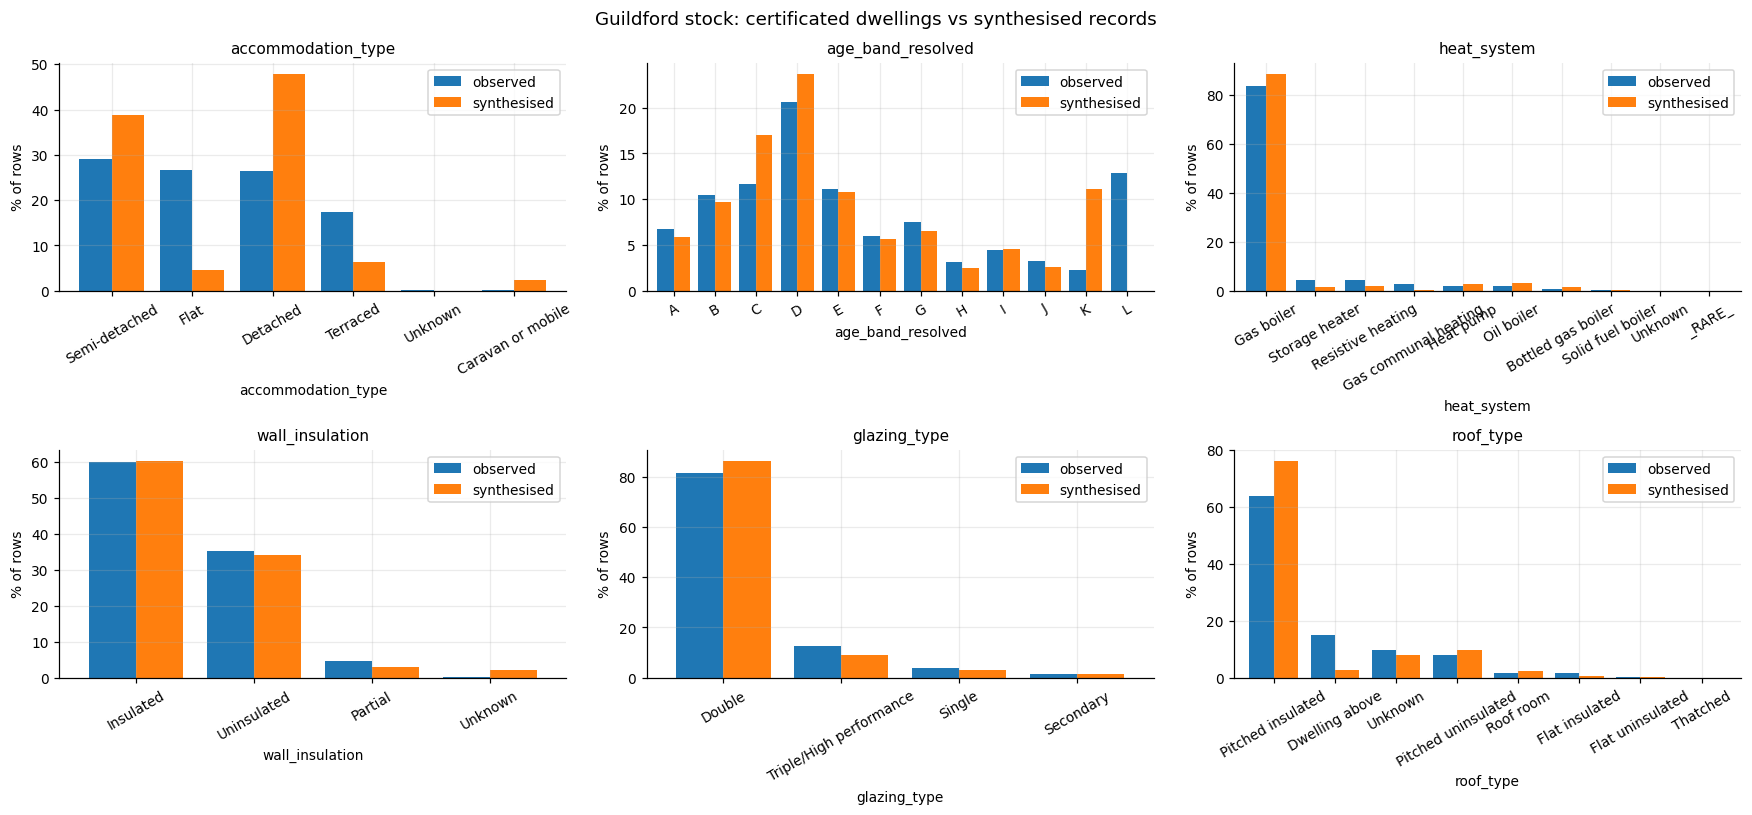

,n,synthesised_share
accommodation_type,,
Detached,18699,42.3
Semi-detached,18243,35.1
Flat,11621,6.5
Terraced,8175,12.7
Caravan or mobile,461,85.2
Unknown,101,0.0


In [3]:
attrs = ["accommodation_type", "age_band_resolved", "heat_system", "wall_insulation", "glazing_type", "roof_type"]
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))
for ax, col in zip(axes.ravel(), attrs):
    o = df.loc[df["attributes_observed"], col].value_counts(normalize=True)
    s = df.loc[~df["attributes_observed"], col].value_counts(normalize=True)
    d = pd.concat([o.rename("observed"), s.rename("synthesised")], axis=1).fillna(0) * 100
    d = d.sort_index() if col == "age_band_resolved" else d
    d.plot.bar(ax=ax, rot=30, width=0.8)
    ax.set_title(col, fontsize=10); ax.set_ylabel("% of rows")
fig.suptitle(f"{STUDY_AREA} stock: certificated dwellings vs synthesised records", fontsize=12)
plt.tight_layout(); fig.savefig(FIG / "00_observed_vs_synthesised.png", bbox_inches="tight"); plt.show()
per_type = df.groupby("accommodation_type")["attributes_observed"].agg(n="size", synthesised_share=lambda s: 100 * (1 - s.mean()))
per_type.round(1).sort_values("n", ascending=False)

In [4]:
degree_days = H.hdd_from_epw(EPW, base_c=15.5)
print(f"Heating degree-days of the weather file {EPW.name}, base 15.5 °C: {degree_days:,.0f} K·day (one weather station for the authority)")

Heating degree-days of the weather file GBR_ENG_Farnborough.AP.037680_TMYx.2007-2021.epw, base 15.5 °C: 1,886 K·day (one weather station for the authority)


## 2 · Build the working tables

In [5]:
num = H.impute_group_median(df, ["storeys_est", "height_eaves_m", "height_ridge_m", "volume_m3"], by="accommodation_type")[NUM_COLS].copy()
num["roof_exposed"] = df["roof_U"].notna().astype(int)         # a null roof U-value means a dwelling above (adiabatic ceiling)
num["roof_U"] = num["roof_U"].fillna(0.0)
num["is_flat_roof"] = df["is_flat_roof"].astype(int)
num["is_observed"] = df["attributes_observed"].astype(int)      # provenance flag (never a model feature)
num["degree_days"] = degree_days
cert = pd.DataFrame({"EPh_sap": df.get("energy_consumption_current"), "sap_co2_m2": df.get("co2_emiss_curr_per_floor_area"),
                     "sap_score": df.get("current_energy_efficiency"), "sap_heating_cost": df.get("heating_cost_current")})
cats = df[CAT_COLS].astype("object").fillna("unknown")
onehot = pd.get_dummies(cats, prefix=CAT_COLS, dtype=int)
onehot.columns = [H.sanitize(c) for c in onehot.columns]
table = pd.concat([num, onehot, cert], axis=1)
table.index = df["dwelling_id"].values; table.index.name = "dwelling_id"
labels = df[["dwelling_id", "UPRN", "toid", "LSOA", "ward", "in_study_area", "postcode", "social_context",
             "attributes_observed", "link_method", "floor_area_source", "age_band_resolved",
             "construction_sa", "systems_sa", "loads_sa", "lon", "lat"] + CAT_COLS
            + [c for c in EXTRA_LABELS if c in df.columns]].copy().set_index("dwelling_id")
table.to_parquet(TABLE_NUMERIC); table.to_csv(TABLE_NUMERIC_CSV); labels.to_parquet(TABLE_LABELS)
print(f"numeric table : {table.shape[0]:,} rows x {table.shape[1]} columns ({len(NUM_COLS)+4} numeric, {onehot.shape[1]} one-hot, {cert.shape[1]} certificate columns)")
print(f"labels table  : {labels.shape[0]:,} rows x {labels.shape[1]} columns")
for p in (TABLE_NUMERIC, TABLE_LABELS, BENCH_LSOA):
    print(f"wrote {p.relative_to(HERE)}  ({p.stat().st_size/1e6:.1f} MB)")
missing = table.isna().sum(); print("columns with missing values (certificate figures exist for certificated rows only):"); print(missing[missing > 0].to_string())

numeric table : 57,300 rows x 69 columns (19 numeric, 46 one-hot, 4 certificate columns)
labels table  : 57,300 rows x 38 columns
wrote data\derived\stock_numeric.parquet  (2.9 MB)
wrote data\derived\stock_labels.parquet  (3.1 MB)
wrote data\derived\benchmark_lsoa_2021.csv  (0.0 MB)
columns with missing values (certificate figures exist for certificated rows only):
EPh_sap             16493
sap_co2_m2          16534
sap_score           16493
sap_heating_cost    16493


## 3 · A first look

In [6]:
key = ["floor_area_final", "area_m2", "storeys_est", "wall_U", "window_U", "roof_U", "age_band_ord", "EPh_sap"]
table[key].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
floor_area_final,57300.0,113.52,80.04,15.00,67.00,90.00,134.60,998.80
area_m2,57300.0,161.17,393.17,1.75,54.25,77.99,131.19,10950.84
storeys_est,57300.0,1.88,0.75,1.00,1.00,2.00,2.00,10.00
wall_U,57300.0,0.88,0.54,0.10,0.40,0.70,1.50,2.50
window_U,57300.0,2.92,0.70,1.80,3.02,3.02,3.02,5.72
roof_U,57300.0,0.48,0.63,0.00,0.16,0.35,0.40,2.30
age_band_ord,57300.0,5.51,3.28,1.00,3.00,4.00,7.00,12.00
EPh_sap,40807.0,215.61,106.85,-221.00,156.00,203.00,262.00,1846.00


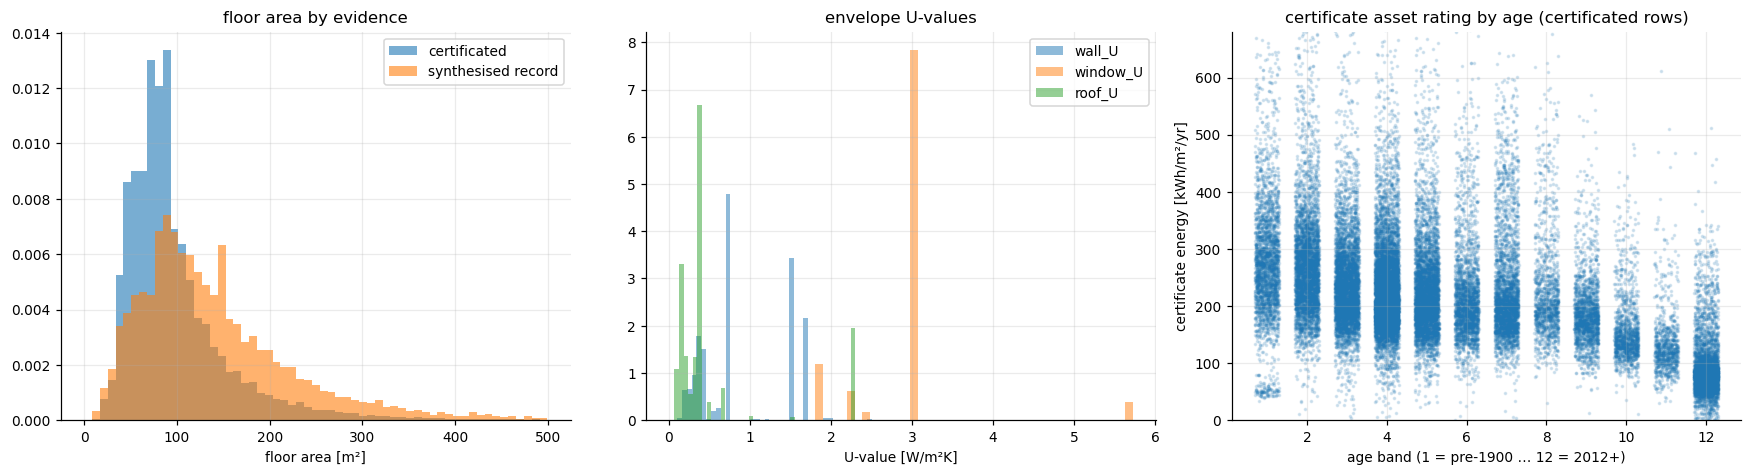

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
obs = table["is_observed"].eq(1)
bins = np.linspace(0, table["floor_area_final"].quantile(0.995), 60)
axes[0].hist(table.loc[obs, "floor_area_final"], bins=bins, alpha=0.6, density=True, label="certificated")
axes[0].hist(table.loc[~obs, "floor_area_final"], bins=bins, alpha=0.6, density=True, label="synthesised record")
axes[0].set_xlabel("floor area [m²]"); axes[0].legend(); axes[0].set_title("floor area by evidence")
for u, c in (("wall_U", "tab:blue"), ("window_U", "tab:orange"), ("roof_U", "tab:green")):
    axes[1].hist(table[u].replace(0, np.nan).dropna(), bins=40, alpha=0.5, label=u, color=c, density=True)
axes[1].set_xlabel("U-value [W/m²K]"); axes[1].legend(); axes[1].set_title("envelope U-values")
o = table.loc[obs & table["EPh_sap"].notna()]
axes[2].scatter(o["age_band_ord"] + np.random.uniform(-0.3, 0.3, len(o)), o["EPh_sap"], s=2, alpha=0.15)
axes[2].set_ylim(0, np.nanpercentile(o["EPh_sap"], 99.5)); axes[2].set_xlabel("age band (1 = pre-1900 … 12 = 2012+)"); axes[2].set_ylabel("certificate energy [kWh/m²/yr]")
axes[2].set_title("certificate asset rating by age (certificated rows)")
plt.tight_layout(); fig.savefig(FIG / "00_first_look.png", bbox_inches="tight"); plt.show()

**Next:** `01_archetypes.ipynb` — construction sub-archetypes per built form and the systems families.